# Задача кластеризации

## Задание №1

Найти данные для кластеризации. Данные в группе не должны
повторяться. Если признаки в данных имеют очень сильно разные
масштабы, то необходимо данные предварительно нормализовать.

In [71]:
import kagglehub
import pandas as pd
import os


path = kagglehub.dataset_download("ekibee/car-sales-information")

file_path = os.path.join(path, "all_regions.csv")
df = pd.read_csv(file_path)

#### Первые N строк

In [72]:
n = 5
df.head(n)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
0,Volkswagen,Golf,Хэтчбек 5 дв.,Серебристый,Бензин,NaN,240000.0,Механика,101.0,280000,NaN,NaN,NaN,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/volkswagen/golf/5001300...,101 л.с. люк не течёт. Документы в порядке. Со...,2023-05-02 01:00:00
1,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/oka/50378140.html,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ...",2023-05-02 20:00:00
2,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/toyota/funcargo/5037751...,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...,2023-05-02 20:00:00
3,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/granta/50382492.html,"Автомобиль в отличном техническом состоянии, н...",2023-05-02 23:00:00
4,Лада,Нива Легенд,Джип 3 дв.,Зеленый,Бензин,NaN,NaN,Механика,83.0,1022900,NaN,NaN,NaN,2023-04-02 00:00:00,Яблоновский,https://yablonovskiy.drom.ru/lada/niva_legend/...,Модель: Нива Легенд Комплектация: LADA (ВАЗ) N...,2023-05-02 20:00:00


#### Общая информация о датасете

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1294757 non-null  object 
 1   name                  1294757 non-null  object 
 2   bodyType              1294757 non-null  object 
 3   color                 1257029 non-null  object 
 4   fuelType              1289815 non-null  object 
 5   year                  724644 non-null   float64
 6   mileage               771799 non-null   float64
 7   transmission          1289563 non-null  object 
 8   power                 1273353 non-null  float64
 9   price                 1294757 non-null  int64  
 10  vehicleConfiguration  724647 non-null   object 
 11  engineName            720976 non-null   object 
 12  engineDisplacement    717625 non-null   object 
 13  date                  1294757 non-null  object 
 14  location              1294757 non-

#### Дубликаты

In [74]:
df.duplicated().sum()

np.int64(0)

#### Пустые значения

In [75]:
df.isna().sum()

brand                        0
name                         0
bodyType                     0
color                    37728
fuelType                  4942
year                    570113
mileage                 522958
transmission              5194
power                    21404
price                        0
vehicleConfiguration    570110
engineName              573781
engineDisplacement      577132
date                         0
location                     0
link                         0
description              40352
parse_date                   0
dtype: int64

#### Удаление строк с пустыми значениями

In [76]:
df.dropna(how="any", inplace=True, ignore_index=True)
df.isna().sum()

brand                   0
name                    0
bodyType                0
color                   0
fuelType                0
year                    0
mileage                 0
transmission            0
power                   0
price                   0
vehicleConfiguration    0
engineName              0
engineDisplacement      0
date                    0
location                0
link                    0
description             0
parse_date              0
dtype: int64

#### Число строк и столбцов

In [77]:
df.shape

(399192, 18)

#### Удаление ненужных столбцов, работа над типами данных

In [78]:
df = df.drop(columns=["link", "parse_date", "description", "date", "location", "engineName", "vehicleConfiguration", "name", "color"])
df.head()

,brand,bodyType,fuelType,year,mileage,transmission,power,price,engineDisplacement
0,Лада,Хэтчбек 3 дв.,Бензин,1996.0,37000.0,Механика,33.0,95000,0.7 LTR
1,Toyota,Хэтчбек 5 дв.,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 LTR
2,Лада,Лифтбек,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 LTR
3,Chevrolet,Джип 5 дв.,Бензин,2002.0,220000.0,Механика,80.0,450000,1.7 LTR
4,Лада,Хэтчбек 5 дв.,Бензин,2007.0,185000.0,Механика,81.0,120000,1.6 LTR


#### Приведение типов данных

In [79]:
df["year"] = df["year"].astype("int64")
df["mileage"] = df["mileage"].astype("int64")
df["power"] = df["power"].astype("int64")
df["engineDisplacement"] = df["engineDisplacement"].str.rstrip("LTR").astype("float64")
df.head()

,brand,bodyType,fuelType,year,mileage,transmission,power,price,engineDisplacement
0,Лада,Хэтчбек 3 дв.,Бензин,1996,37000,Механика,33,95000,0.7
1,Toyota,Хэтчбек 5 дв.,Бензин,2002,295000,АКПП,87,380000,1.3
2,Лада,Лифтбек,Бензин,2018,16000,Механика,106,795000,1.6
3,Chevrolet,Джип 5 дв.,Бензин,2002,220000,Механика,80,450000,1.7
4,Лада,Хэтчбек 5 дв.,Бензин,2007,185000,Механика,81,120000,1.6


#### One-hot encoding

In [80]:
df = pd.get_dummies(df, columns=["transmission", "fuelType", "bodyType"])
df

,brand,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,...,bodyType_Джип 5 дв.,bodyType_Купе,bodyType_Лифтбек,bodyType_Минивэн,bodyType_Открытый,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.
0,Лада,1996,37000,33,95000,0.7,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
1,Toyota,2002,295000,87,380000,1.3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,Лада,2018,16000,106,795000,1.6,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3,Chevrolet,2002,220000,80,450000,1.7,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4,Лада,2007,185000,81,120000,1.6,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,Chevrolet,2008,280000,109,550000,1.6,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
399188,Лада,1985,300000,64,165000,1.3,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
399189,Toyota,2020,32000,202,3100000,2.5,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
399190,Лада,1995,354000,79,298000,1.7,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [81]:
luxury_brands = ['BMW', 'Audi', 'Mercedes-Benz', 'Lexus', 'Porsche', 'Land Rover', 
                 'Infiniti', 'Volvo', 'Jaguar', 'Cadillac', 'Lincoln', 'Acura', 
                 'Bentley', 'Genesis', 'McLaren', 'Ferrari', 'Rolls-Royce', 'Maserati', 
                 'Aston Martin', 'Maybach']

premium_brands = ['Volkswagen', 'Toyota', 'Honda', 'Nissan', 'Mazda', 'Subaru', 
                  'Hyundai', 'Kia', 'Ford', 'Opel', 'Peugeot', 'Citroen', 'Skoda', 
                  'Renault', 'Chevrolet', 'Mitsubishi', 'Suzuki', 'Mini', 'Saab']

budget_brands = ['Лада', 'ГАЗ', 'УАЗ', 'ИЖ', 'ЗАЗ', 'ЛуАЗ', 'ТагАЗ', 'Богдан', 'Москвич',
                 'Dacia', 'Lada', 'ВАЗ']

chinese_brands = ['Chery', 'Haval', 'Great Wall', 'Geely', 'BYD', 'Changan', 'JAC', 
                  'EXEED', 'Li', 'GAC', 'Zotye', 'Dongfeng', 'FAW', 'Haima', 'Brilliance']

other_brands = [brand for brand in df['brand'].unique() 
                if brand not in luxury_brands + premium_brands + budget_brands + chinese_brands]


def map_brand_segment(brand):
    if brand in luxury_brands:
        return 'luxury'
    elif brand in premium_brands:
        return 'premium'
    elif brand in budget_brands:
        return 'budget'
    elif brand in chinese_brands:
        return 'chinese'
    else:
        return 'other'

df['brand_segment'] = df['brand'].apply(map_brand_segment)
df

,brand,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,...,bodyType_Купе,bodyType_Лифтбек,bodyType_Минивэн,bodyType_Открытый,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_segment
0,Лада,1996,37000,33,95000,0.7,False,False,True,False,...,False,False,False,False,False,False,False,True,False,budget
1,Toyota,2002,295000,87,380000,1.3,True,False,False,False,...,False,False,False,False,False,False,False,False,True,premium
2,Лада,2018,16000,106,795000,1.6,False,False,True,False,...,False,True,False,False,False,False,False,False,False,budget
3,Chevrolet,2002,220000,80,450000,1.7,False,False,True,False,...,False,False,False,False,False,False,False,False,False,premium
4,Лада,2007,185000,81,120000,1.6,False,False,True,False,...,False,False,False,False,False,False,False,False,True,budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,Chevrolet,2008,280000,109,550000,1.6,True,False,False,False,...,False,False,False,False,False,True,False,False,False,premium
399188,Лада,1985,300000,64,165000,1.3,False,False,True,False,...,False,False,False,False,False,True,False,False,False,budget
399189,Toyota,2020,32000,202,3100000,2.5,True,False,False,False,...,False,False,False,False,False,True,False,False,False,premium
399190,Лада,1995,354000,79,298000,1.7,False,False,True,False,...,False,False,False,False,False,False,False,False,False,budget


#### One-hot encoding

In [82]:
df = pd.get_dummies(df, columns=['brand_segment'], prefix='brand')
df = df.drop(columns = ["brand"])
df

,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,fuelType_Бензин,...,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_budget,brand_chinese,brand_luxury,brand_other,brand_premium
0,1996,37000,33,95000,0.7,False,False,True,False,True,...,False,False,False,True,False,True,False,False,False,False
1,2002,295000,87,380000,1.3,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,2018,16000,106,795000,1.6,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False
3,2002,220000,80,450000,1.7,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
4,2007,185000,81,120000,1.6,False,False,True,False,True,...,False,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399187,2008,280000,109,550000,1.6,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
399188,1985,300000,64,165000,1.3,False,False,True,False,True,...,False,True,False,False,False,True,False,False,False,False
399189,2020,32000,202,3100000,2.5,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
399190,1995,354000,79,298000,1.7,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False


#### Удаление выбросов

In [83]:
z_thresh = 3

means = df.mean()
stds = df.std(ddof=0)
z_scores = (df - means) / stds

mask = (z_scores.abs() <= z_thresh).all(axis=1)

df = df[mask].reset_index(drop=True)
df


,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,fuelType_Бензин,...,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_budget,brand_chinese,brand_luxury,brand_other,brand_premium
0,2002,295000,87,380000,1.3,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
1,2002,220000,80,450000,1.7,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
2,2007,185000,81,120000,1.6,False,False,True,False,True,...,False,False,False,False,True,True,False,False,False,False
3,2020,26000,144,2730000,2.0,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,2008,305000,81,165000,1.6,False,False,True,False,True,...,False,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245179,2017,93000,80,890000,1.7,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
245180,2008,280000,109,530000,1.6,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
245181,2008,280000,109,550000,1.6,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
245182,1985,300000,64,165000,1.3,False,False,True,False,True,...,False,True,False,False,False,True,False,False,False,False


#### Масштабирование признаков

In [84]:
from sklearn.preprocessing import StandardScaler


numerical_features = ['year', 'mileage', 'power', 'price', 'engineDisplacement']
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df

,year,mileage,power,price,engineDisplacement,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,fuelType_Бензин,...,bodyType_Пикап,bodyType_Седан,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,brand_budget,brand_chinese,brand_luxury,brand_other,brand_premium
0,-0.687692,1.399363,-0.864754,-0.642401,-0.968362,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
1,-0.687692,0.603539,-0.993907,-0.558278,-0.305319,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
2,-0.076239,0.232155,-0.975456,-0.954858,-0.471080,False,False,True,False,True,...,False,False,False,False,True,True,False,False,False,False
3,1.513540,-1.454991,0.186915,2.181731,0.191963,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,0.046052,1.505472,-0.975456,-0.900779,-0.471080,False,False,True,False,True,...,False,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245179,1.146668,-0.744056,-0.993907,-0.029504,-0.305319,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,True
245180,0.046052,1.240198,-0.458847,-0.462137,-0.471080,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
245181,0.046052,1.240198,-0.458847,-0.438102,-0.471080,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
245182,-2.766633,1.452417,-1.289112,-0.900779,-0.968362,False,False,True,False,True,...,False,True,False,False,False,True,False,False,False,False


## Задание №2

Провести кластеризацию данных с помощью алгоритма k-means.
Использовать «правило локтя» и коэффициент силуэта для поиска
оптимального количества кластеров.

In [108]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.utils import resample


df_sample = resample(df, n_samples=10000, random_state=42, stratify=None)
inertias = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, init="k-means++", n_init=3, max_iter = 100)
    model.fit(df_sample)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(df_sample, model.fit_predict(df_sample)))

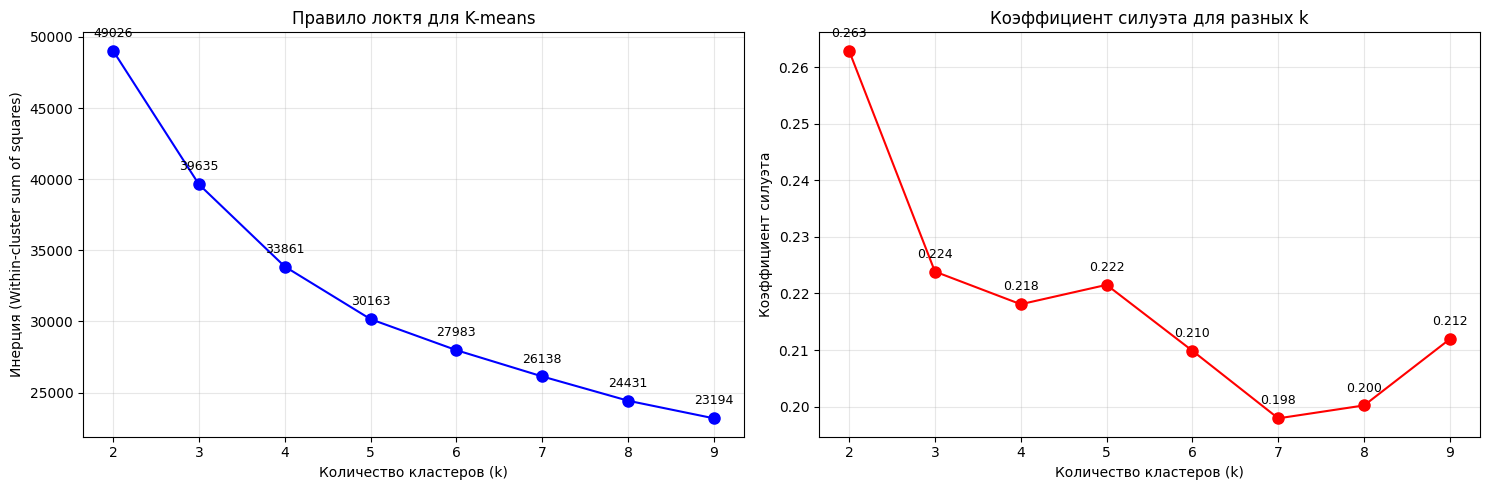

In [109]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-', markersize=8)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция (Within-cluster sum of squares)')
plt.title('Правило локтя для K-means')
plt.grid(True, alpha=0.3)

for i, (k, inertia) in enumerate(zip(k_range, inertias)):
    plt.annotate(f'{inertia:.0f}', (k, inertia), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-', markersize=8)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Коэффициент силуэта')
plt.title('Коэффициент силуэта для разных k')
plt.grid(True, alpha=0.3)

for i, (k, score) in enumerate(zip(k_range, silhouette_scores)):
    plt.annotate(f'{score:.3f}', (k, score), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [125]:
model_kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = model_kmeans.fit_predict(df_sample)
cluster_centers = model_kmeans.cluster_centers_

## Задание №3

Провести кластеризацию данных с помощью алгоритма иерархической
кластеризации.


In [132]:
from sklearn.cluster import AgglomerativeClustering


agg_clustering = AgglomerativeClustering(n_clusters=2)
agg_labels = agg_clustering.fit_predict(df_sample)

## Задание №4

Провести кластеризацию данных с помощью алгоритма DBSCAN.

In [116]:
from sklearn.cluster import DBSCAN


model_dbscan = DBSCAN()
model_dbscan.fit(df_sample)
model_dbscan.labels_

array([ 0,  1,  8, ..., 16,  3,  1], shape=(10000,))

## Задание №5

Визуализировать кластеризованные данные с помощью t-SNE или
UMAP, если необходимо. Если данные трехмерные, то можно
использовать трехмерный точечный график.

### K-Means

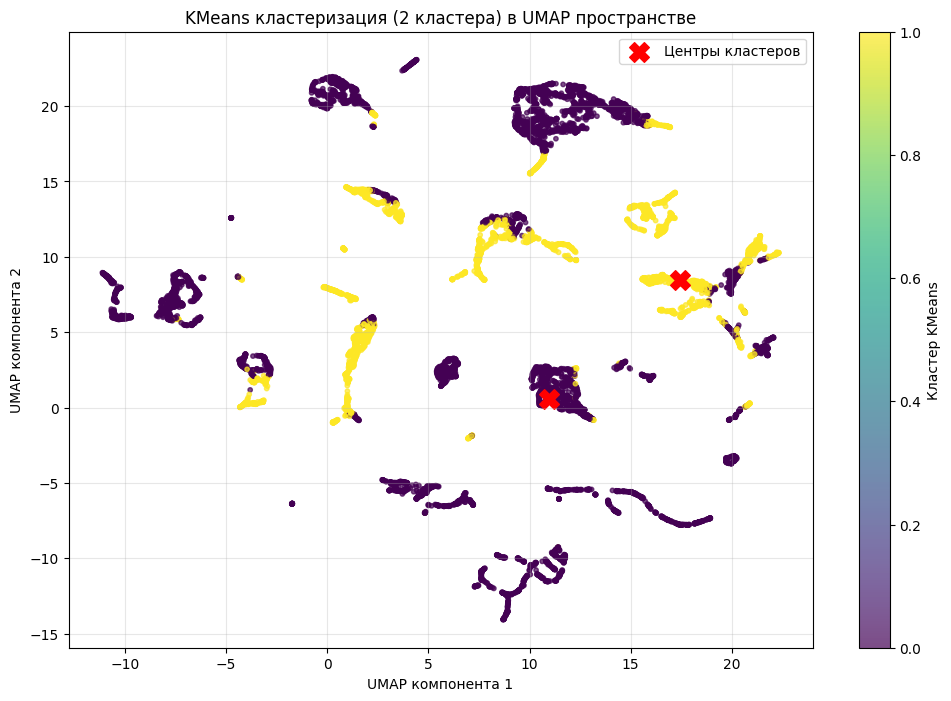

In [127]:
import umap


reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(df_sample)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(embedding[:, 0], embedding[:, 1], 
                     c=kmeans_labels, cmap='viridis', alpha=0.7, s=10)

centers_embedding = reducer.transform(cluster_centers)
plt.scatter(centers_embedding[:, 0], centers_embedding[:, 1],
           c='red', marker='X', s=200, alpha=1, label='Центры кластеров')

plt.colorbar(scatter, label='Кластер KMeans')
plt.title('KMeans кластеризация (2 кластера) в UMAP пространстве')
plt.xlabel('UMAP компонента 1')
plt.ylabel('UMAP компонента 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Agglomerative Clustering

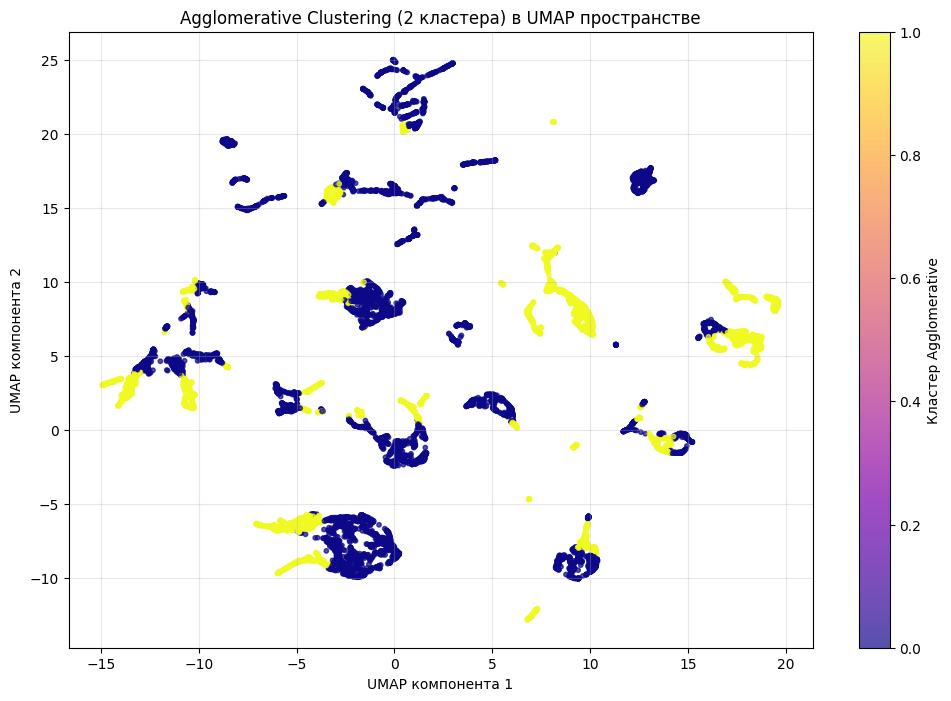

In [135]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(df_sample)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(embedding[:, 0], embedding[:, 1], 
                     c=agg_labels, cmap='plasma', alpha=0.7, s=10)

plt.colorbar(scatter, label='Кластер Agglomerative')
plt.title('Agglomerative Clustering (2 кластера) в UMAP пространстве')
plt.xlabel('UMAP компонента 1')
plt.ylabel('UMAP компонента 2')
plt.grid(True, alpha=0.3)
plt.show()